<a href="https://colab.research.google.com/github/KrasnovaOV/A-B-test/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%C2%AB%D0%9F%D1%80%D0%BE%D0%B2%D0%BE%D0%B4%D0%B8%D0%BC_%D0%90_B_%D1%82%D0%B5%D1%81%D1%82_1%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задание:**
Используя тестовый датасет, разделите пользователей на две группы. Проверьте качество рандомизации и балансировку групп.

**Цель задания:**
Научиться распределять пользователей на группы и проверять распределение на качество рандомизации и балансировки.

**Материалы к заданию:**
· Тестовый датасет в формате xlsx (для Excel)Как работать с файлом
· Тестовый датасет в формате csv (для Python)

**Инструменты:**
· Google Colab
· Excel

**Инструкция по выполнению:**
Вы можете выбрать любой из вариантов выполнения задания: если вы умеете пользоваться Python, выбирайте вариант 1, если нет — вариант 2.

Вариант 1. Python
Шаг 1. Импорт датасета.
Выполняйте работу в Google Colab. Скачайте и импортируйте датасет.

Шаг 2. Хешируйте user_id.
Преобразуйте user_id к строке, если нужно. Получите хеш от этой строки. Можно использовать хеш-функции, например, MD5 или SHA-1.

Шаг 3. Получите остаток от деления.
Возьмите полученное число из хеша и разделите на 100, возьмите остаток (операция modulo).

Шаг 4. Определите группу пользователя.

Установите пороговое значение для разделения на группы.
Например, 50:
· Если group_index < 50: пользователь относится к группе А
· Если group_index >= 50: пользователь относится к группе B

Шаг 5. Проверьте балансировку групп.
Посчитайте, сколько пользователей попало в каждую группу. Хороший результат — примерно 50 на 50.

Шаг 6. Проверьте рандомизацию групп.
- Проверьте, равномерно ли распределены группы по другим признакам (age, region, и т. п.):
- Получите фактическое количество пользователей в каждой группе.
- Рассчитайте соотношение между группами. Найдите абсолютное и относительное отклонение:
a. Абсолютное: (A — B)
b. Относительное: ((А-В))/(среднее (А,В)х 100%)
- Сравните результат с допустимым порогом отклонения:
a. Идеально: разница не превышает ±5%
b. Критично: более 10%
Например: 5 500 vs 4 500 — это 18% отклонение
- Сделайте вывод:
a. Если разница в пределах нормы, рандомизация качественная.
b. Если превышает критический порог (>10%), рандомизация требует доработки.
c. Если требуется доработка, проанализируйте причины дисбаланса и предложите решение.
Проверьте также рандомизацию участников по ключевым признакам.
Важно, чтобы средняя и медиана в обеих группах была примерно одинаковая, а также распределение по полу и региону тоже имело примерно равное значение.

Шаг 7. Подготовьте результаты работы к сдаче.
В вашем блокноте Google Colab:

Нажмите кнопку «Поделиться» в правом верхнем углу блокнота.
В окне измените настройки доступа на «Все, у кого есть ссылка».
Выберите уровень доступа «Редактор».
Скопируйте ссылку и предоставьте её в качестве вашей работы.

Чек-лист для самопроверки:
· Пользователи разделены на две группы А и B.
· Проведена проверка балансировки групп.
· Проведена проверка рандомизации.
· Описан вывод по результатам работы.

**Шаг 1. Импорт библиотек и набора данных**

In [1]:
import pandas as pd
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, chi2_contingency

# Настройки отображения
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Загрузка файла с компьютера
from google.colab import files

uploaded = files.upload()

Saving new_dataframe.csv to new_dataframe.csv


In [2]:
file_name = "new_dataframe.csv"

df = pd.read_csv(file_name)

print("Датасет успешно загружен.")
print("Количество строк:", len(df))
print("Количество столбцов:", df.shape[1])

display(df.head())

Датасет успешно загружен.
Количество строк: 101500
Количество столбцов: 15


,Unnamed: 0,user_id,hour,os,order_class,surge,app_opened,price_seen,order_made,ride_completed,user_cancelled,city_center_order,distance,age,rfm
0,0,867689,12,iOS,business,no surge,1,1,1,1,0,0,7.982,20,low
1,1,752172,5,Android,economy,no surge,1,1,1,1,0,1,2.908,27,high
2,2,486559,15,Android,comfort,no surge,1,1,1,1,0,0,7.225,21,high
3,3,304024,0,Android,economy,no surge,1,1,1,1,0,1,1.874,52,low
4,4,139420,0,Android,business,no surge,1,1,1,1,0,0,10.705,19,low


In [3]:
# Проверяем структуру данных:
print("Названия столбцов:")
print(df.columns.tolist())

print("\nТипы данных:")
display(df.dtypes)

print("\nКоличество пропусков:")
display(df.isna().sum())

Названия столбцов:
['Unnamed: 0', 'user_id', 'hour', 'os', 'order_class', 'surge', 'app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'city_center_order', 'distance', 'age', 'rfm']

Типы данных:


,0
Unnamed: 0,int64
user_id,int64
hour,int64
os,object
order_class,object
surge,object
app_opened,int64
price_seen,int64
order_made,int64
ride_completed,int64



Количество пропусков:


,0
Unnamed: 0,0
user_id,0
hour,0
os,0
order_class,0
surge,10069
app_opened,0
price_seen,0
order_made,0
ride_completed,0


In [4]:
# Проверим количество строк и уникальных пользователей:
rows_count = len(df)
unique_users_count = df["user_id"].nunique()
duplicate_rows_count = df["user_id"].duplicated().sum()

print("Количество строк:", rows_count)
print("Количество уникальных пользователей:", unique_users_count)
print("Количество повторных строк пользователей:", duplicate_rows_count)

Количество строк: 101500
Количество уникальных пользователей: 24224
Количество повторных строк пользователей: 77276


Поскольку один пользователь встречается несколько раз, группу нужно назначать на уровне user_id.

In [5]:
# Проверяем количество записей на одного пользователя:
user_activity = df.groupby("user_id").size()

print("Среднее количество строк на пользователя:",
      round(user_activity.mean(), 2))

print("Минимальное количество строк на пользователя:",
      user_activity.min())

print("Максимальное количество строк на пользователя:",
      user_activity.max())

display(user_activity.describe().round(2))

Среднее количество строк на пользователя: 4.19
Минимальное количество строк на пользователя: 1
Максимальное количество строк на пользователя: 14


,0
count,24224.000
mean,4.190
std,1.980
min,1.000
25%,3.000
50%,4.000
75%,5.000
max,14.000


In [6]:
# Если в наборе данных есть технический столбец Unnamed: 0, удалим его:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Текущие столбцы:")
print(df.columns.tolist())

Текущие столбцы:
['user_id', 'hour', 'os', 'order_class', 'surge', 'app_opened', 'price_seen', 'order_made', 'ride_completed', 'user_cancelled', 'city_center_order', 'distance', 'age', 'rfm']


**Создание таблицы уникальных пользователей**

Создадим отдельную таблицу, в которой каждый пользователь будет представлен только один раз:

In [7]:
users = df[["user_id"]].drop_duplicates().reset_index(drop=True)

print("Количество уникальных пользователей:", len(users))
display(users.head())

Количество уникальных пользователей: 24224


,user_id
0,867689
1,752172
2,486559
3,304024
4,139420


In [8]:
# Проверим, что каждый user_id встречается только один раз:
print(
    "Количество дубликатов в таблице users:",
    users["user_id"].duplicated().sum()
)

Количество дубликатов в таблице users: 0


**Шаг 2. Хеширование user_id**

Преобразуем user_id в строку и получаем хеш с помощью MD5:

In [9]:
def hash_user_id(uid):
    uid_str = str(uid)
    uid_hash = hashlib.md5(
        uid_str.encode("utf-8")
    ).hexdigest()

    return int(uid_hash, 16)

In [10]:
# Применим функцию к уникальным пользователям:
users["user_hash"] = users["user_id"].apply(hash_user_id)

display(users.head())

,user_id,user_hash
0,867689,207021514915257020430936527496092606591
1,752172,275782213665482290192042867242558471677
2,486559,103266185129541807356797093470683387217
3,304024,3734281640716273381446497663233150109
4,139420,11112181322636506944205271446330541724


In [11]:
# Проверим, есть ли у каждого пользователя хеш:
print(
    "Количество пропусков в user_hash:",
    users["user_hash"].isna().sum()
)

Количество пропусков в user_hash: 0


**Шаг 3. Получение остатка от деления**

Возьмём остаток от деления хеша на 100:

In [12]:
users["group_index"] = users["user_hash"] % 100

display(
    users[["user_id", "user_hash", "group_index"]].head()
)

,user_id,user_hash,group_index
0,867689,207021514915257020430936527496092606591,91
1,752172,275782213665482290192042867242558471677,77
2,486559,103266185129541807356797093470683387217,17
3,304024,3734281640716273381446497663233150109,9
4,139420,11112181322636506944205271446330541724,24


In [13]:
# Проверяем диапазон значений:
print("Минимальное значение group_index:",
      users["group_index"].min())

print("Максимальное значение group_index:",
      users["group_index"].max())

Минимальное значение group_index: 0
Максимальное значение group_index: 99


**Шаг 4. Распределение по группам A и B**

Используем порог 50:
- group_index < 50 — группа А;
- group_index >= 50 — группа Б.

In [14]:
users["group"] = np.where(
    users["group_index"] < 50,
    "A",
    "B"
)

display(
    users[["user_id", "group_index", "group"]].head()
)

,user_id,group_index,group
0,867689,91,B
1,752172,77,B
2,486559,17,A
3,304024,9,A
4,139420,24,A


In [15]:
# Проверим, что группы содержат только значения A и B:
print(users["group"].unique())

['B' 'A']


In [16]:
# Проверим, что один пользователь не попал одновременно в несколько групп:
groups_per_user = users.groupby("user_id")["group"].nunique()

print(
    "Максимальное количество групп на одного пользователя:",
    groups_per_user.max()
)

if groups_per_user.max() == 1:
    print("Каждый пользователь находится только в одной группе.")
else:
    print("Ошибка: пользователи находятся в нескольких группах.")

Максимальное количество групп на одного пользователя: 1
Каждый пользователь находится только в одной группе.


**Шаг 5. Проверка балансировки групп**

Важно: проверяем балансировку по таблице users, поскольку в ней на каждого пользователя приходится по одной строке.

In [17]:
group_counts = users["group"].value_counts().reindex(
    ["A", "B"],
    fill_value=0
)

group_percent = (
    users["group"]
    .value_counts(normalize=True)
    .reindex(["A", "B"], fill_value=0)
    * 100
)

balance_table = pd.DataFrame({
    "Количество пользователей": group_counts,
    "Доля пользователей, %": group_percent.round(2)
})

display(balance_table)

,Количество пользователей,"Доля пользователей, %"
group,,
A,12082,49.880
B,12142,50.120


**Шаг 6. Проверьте рандомизацию групп.**

Расчет абсолютного и относительного отклонения

In [18]:
A_count = group_counts["A"]
B_count = group_counts["B"]

absolute_diff = abs(A_count - B_count)

average_group_size = (A_count + B_count) / 2

relative_diff = (
    absolute_diff / average_group_size * 100
)

print("Количество пользователей в группе A:", A_count)
print("Количество пользователей в группе B:", B_count)
print("Абсолютное отклонение:", absolute_diff)
print(f"Относительное отклонение: {relative_diff:.2f}%")

Количество пользователей в группе A: 12082
Количество пользователей в группе B: 12142
Абсолютное отклонение: 60
Относительное отклонение: 0.50%


In [19]:
# Оценим результат по условиям задания:
if relative_diff <= 5:
    print(
        "Идеально: разница между группами не превышает 5%. "
        "Рандомизация качественная."
    )
elif relative_diff <= 10:
    print(
        "Допустимо: разница находится в диапазоне от 5% до 10%. "
        "Группы можно использовать, но следует быть внимательным."
    )
else:
    print(
        "Критично: разница превышает 10%. "
        "Рандомизация требует доработки."
    )

Идеально: разница между группами не превышает 5%. Рандомизация качественная.


**Визуализация размера групп**

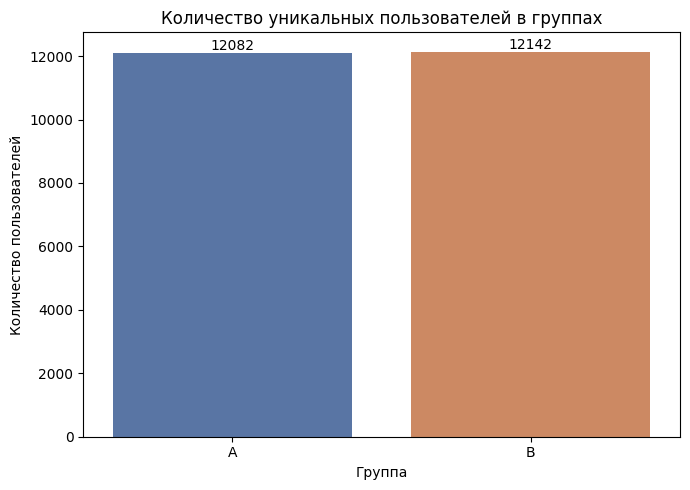

In [45]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=group_counts.index,
    y=group_counts.values,
    hue=group_counts.index,
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title("Количество уникальных пользователей в группах")
plt.xlabel("Группа")
plt.ylabel("Количество пользователей")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

**Добавление группы в исходный набор данных**

Теперь присоединим группу обратно ко всем строкам исходного набора данных:

In [21]:
df = df.merge(
    users[["user_id", "group"]],
    on="user_id",
    how="left"
)

print("Количество строк после объединения:", len(df))
print("Количество пропусков в group:", df["group"].isna().sum())
print("Количество уникальных пользователей:", df["user_id"].nunique())

Количество строк после объединения: 101500
Количество пропусков в group: 0
Количество уникальных пользователей: 24224


In [22]:
# Количество строк должно остаться равным исходному значению:
if len(df) == rows_count:
    print("Количество строк не изменилось.")
else:
    print("Внимание: количество строк изменилось.")

Количество строк не изменилось.


In [23]:
# Проверим, что у каждого пользователя только одна группа:
check_groups = df.groupby("user_id")["group"].nunique()

if check_groups.max() == 1:
    print("Все строки одного пользователя имеют одну и ту же группу.")
else:
    print("Ошибка: один пользователь имеет несколько групп.")

Все строки одного пользователя имеют одну и ту же группу.


**Создание пользовательской таблицы для проверки признаков**

Поскольку пользователи повторяются в исходном наборе данных, признаки будем проверять на уровне пользователей.

Для числовых признаков используем среднее значение, а для категориальных — первое значение:

In [24]:
user_level = (
    df.groupby(["user_id", "group"], as_index=False)
      .agg({
          "age": "first",
          "hour": "mean",
          "os": "first",
          "order_class": "first",
          "surge": "first",
          "distance": "mean",
          "rfm": "first"
      })
)

print("Размер пользовательской таблицы:", user_level.shape)

display(user_level.head())

Размер пользовательской таблицы: (24224, 9)


,user_id,group,age,hour,os,order_class,surge,distance,rfm
0,100093,B,21,6.000,iOS,comfort,no surge,5.341,low
1,100118,B,26,14.400,iOS,economy,no surge,4.948,low
2,100134,A,25,16.800,iOS,business,surge,7.744,low
3,100166,B,18,9.400,Android,economy,no surge,4.215,high
4,100255,B,27,10.444,iOS,economy,no surge,6.199,low


In [25]:
# Проверим количество пользователей в этой таблице:
print(
    "Количество пользователей в user_level:",
    user_level["user_id"].nunique()
)

Количество пользователей в user_level: 24224


**Проверка возраста**

In [26]:
age_statistics = (
    user_level
    .groupby("group")["age"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(2)
)

display(age_statistics)

,count,mean,median,std,min,max
group,,,,,,
A,12082,27.890,25.000,9.500,18,69
B,12142,27.810,25.000,9.460,18,69


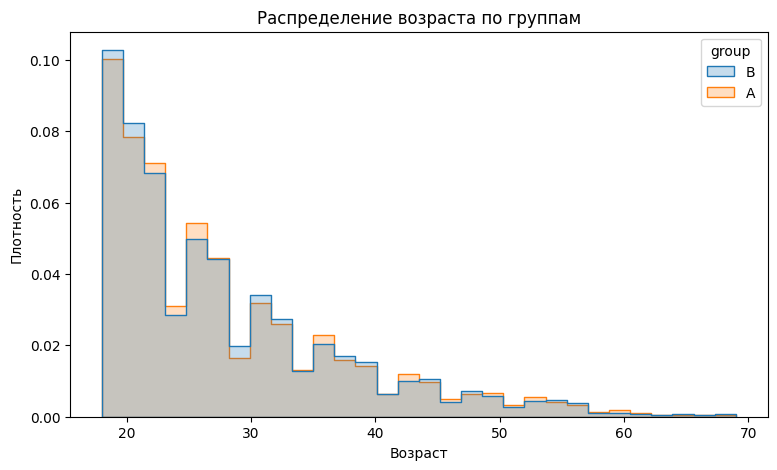

In [27]:
# Визуализируем распределение по возрасту:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=user_level,
    x="age",
    hue="group",
    bins=30,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Распределение возраста по группам")
plt.xlabel("Возраст")
plt.ylabel("Плотность")
plt.show()

In [30]:
# Проверим разницу средних значений возраста с помощью t-критерия:
age_A = user_level.loc[
    user_level["group"] == "A",
    "age"
].dropna()

age_B = user_level.loc[
    user_level["group"] == "B",
    "age"
].dropna()

age_test = ttest_ind(
    age_A,
    age_B,
    equal_var=False
)

print(f"t-статистика: {age_test.statistic:.4f}")
print(f"p-value: {age_test.pvalue:.4f}")

if age_test.pvalue < 0.05:
    print(
        "Средний возраст статистически значимо отличается "
        "между группами."
    )
else:
    print(
        "Статистически значимых различий в возрасте "
        "между группами не обнаружено."
    )

t-статистика: 0.6747
p-value: 0.4999
Статистически значимых различий в возрасте между группами не обнаружено.


**Проверка категориальных признаков**

Создадим функцию для проверки признаков os, order_class, surge и rfm:

In [33]:
def check_categorical_feature(data, column):
    print("=" * 60)
    print(f"Проверка признака: {column}")

    counts = pd.crosstab(
        data["group"],
        data[column]
    ).reindex(["A", "B"], fill_value=0)

    percentages = (
        pd.crosstab(
            data["group"],
            data[column],
            normalize="index"
        )
        .reindex(["A", "B"], fill_value=0)
        * 100
    )

    print("\nКоличество пользователей:")
    display(counts)

    print("Распределение внутри групп, %:")
    display(percentages.round(2))

    chi2, p_value, degrees_of_freedom, expected = (
        chi2_contingency(counts)
    )

    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print(
            "Есть статистически значимые различия "
            "между группами."
        )
    else:
        print(
            "Статистически значимых различий "
            "между группами не обнаружено."
        )

    return {
        "Признак": column,
        "p-value": p_value,
        "Различие статистически значимо": p_value < 0.05
    }

In [32]:
# Запустим проверку доступных категориальных признаков:
categorical_columns = [
    "os",
    "order_class",
    "surge",
    "rfm"
]

categorical_results = []

for column in categorical_columns:
    if column in user_level.columns:
        result = check_categorical_feature(
            user_level,
            column
        )
        categorical_results.append(result)

Проверка признака: os

Количество пользователей:


os,Android,iOS
group,,
A,6702,5380
B,6755,5387


Распределение внутри групп, %:


os,Android,iOS
group,,
A,55.470,44.530
B,55.630,44.370


p-value: 0.8093
Статистически значимых различий между группами не обнаружено.
Проверка признака: order_class

Количество пользователей:


...

p-value: 0.9991
Статистически значимых различий между группами не обнаружено.
Проверка признака: rfm

Количество пользователей:


rfm,high,low,medium
group,,,
A,4789,6350,943
B,4810,6439,893


Распределение внутри групп, %:


rfm,high,low,medium
group,,,
A,39.640,52.560,7.800
B,39.610,53.030,7.350


p-value: 0.3909
Статистически значимых различий между группами не обнаружено.


In [34]:
# Сформируем итоговую таблицу:
categorical_results_df = pd.DataFrame(
    categorical_results
)

display(categorical_results_df.round(4))

,Признак,p-value,Различие статистически значимо
0,os,0.809,False
1,order_class,0.269,False
2,surge,0.999,False
3,rfm,0.391,False


**Проверка числовых признаков**

Проверим age, hour и distance.

In [35]:
numeric_columns = [
    "age",
    "hour",
    "distance"
]

numeric_results = []

for column in numeric_columns:
    if column not in user_level.columns:
        continue

    values_A = user_level.loc[
        user_level["group"] == "A",
        column
    ].dropna()

    values_B = user_level.loc[
        user_level["group"] == "B",
        column
    ].dropna()

    test_result = ttest_ind(
        values_A,
        values_B,
        equal_var=False
    )

    numeric_results.append({
        "Признак": column,
        "Среднее A": values_A.mean(),
        "Среднее B": values_B.mean(),
        "Медиана A": values_A.median(),
        "Медиана B": values_B.median(),
        "p-value": test_result.pvalue,
        "Различие статистически значимо": (
            test_result.pvalue < 0.05
        )
    })

numeric_results_df = pd.DataFrame(numeric_results)

display(numeric_results_df.round(4))

,Признак,Среднее A,Среднее B,Медиана A,Медиана B,p-value,Различие статистически значимо
0,age,27.893,27.811,25.000,25.000,0.500,False
1,hour,11.459,11.532,11.500,11.500,0.148,False
2,distance,5.363,5.369,5.010,5.004,0.846,False


**Проверка поведенческих признаков**

Проверяем долю пользователей, совершающих различные действия:

In [36]:
behavior_columns = [
    "app_opened",
    "price_seen",
    "order_made",
    "ride_completed",
    "user_cancelled",
    "city_center_order"
]

behavior_columns = [
    column for column in behavior_columns
    if column in df.columns
]

In [37]:
# Для каждого пользователя рассчитаем средние значения бинарных признаков:
behavior_by_user = (
    df.groupby(["user_id", "group"], as_index=False)
      [behavior_columns]
      .mean()
)

display(behavior_by_user.head())

,user_id,group,app_opened,price_seen,order_made,ride_completed,user_cancelled,city_center_order
0,100093,B,1.000,1.000,0.750,0.750,0.000,0.250
1,100118,B,1.000,1.000,1.000,0.800,0.200,0.000
2,100134,A,1.000,1.000,0.800,0.600,0.200,0.400
3,100166,B,1.000,1.000,0.800,0.600,0.200,0.200
4,100255,B,1.000,1.000,0.556,0.444,0.111,0.444


In [38]:
# Сравним показатели по группам:
behavior_statistics = (
    behavior_by_user
    .groupby("group")[behavior_columns]
    .mean()
    * 100
)

print("Доля пользователей с соответствующим действием, %:")
display(behavior_statistics.round(2))

Доля пользователей с соответствующим действием, %:


,app_opened,price_seen,order_made,ride_completed,user_cancelled,city_center_order
group,,,,,,
A,100.000,90.270,73.360,62.060,11.300,56.970
B,100.000,90.020,73.210,62.340,10.870,57.440


In [41]:
# Проверим статистическую значимость различий:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

behavior_results = []

for column in behavior_columns:

    # Убираем пропуски только для текущего признака
    data = behavior_by_user[
        ["group", column]
    ].dropna()

    # Приводим значения к бинарному формату 0/1
    data[column] = data[column].round().astype(int)

    # Таблица количества значений 0 и 1
    contingency_table = pd.crosstab(
        data["group"],
        data[column]
    ).reindex(
        index=["A", "B"],
        columns=[0, 1],
        fill_value=0
    )

    print(f"\nПризнак: {column}")
    display(contingency_table)

    # Размеры групп
    total_A = contingency_table.loc["A"].sum()
    total_B = contingency_table.loc["B"].sum()

    # Количество единиц
    positive_A = contingency_table.loc["A", 1]
    positive_B = contingency_table.loc["B", 1]

    # Доли единиц в группах
    share_A = positive_A / total_A * 100 if total_A > 0 else np.nan
    share_B = positive_B / total_B * 100 if total_B > 0 else np.nan

    # Проверяем, есть ли в таблице оба значения 0 и 1
    # и есть ли данные в обеих группах
    if (
        contingency_table.shape == (2, 2)
        and contingency_table.to_numpy().sum() > 0
        and (contingency_table.sum(axis=0) > 0).all()
        and (contingency_table.sum(axis=1) > 0).all()
    ):
        chi2_stat, p_value, dof, expected = chi2_contingency(
            contingency_table
        )

        test_comment = "Критерий хи-квадрат"

    else:
        # Если один из вариантов отсутствует,
        # статистический тест не применяем
        chi2_stat = np.nan
        p_value = np.nan

        if contingency_table[0].sum() == 0:
            test_comment = (
                "Все значения равны 1; тест не применяется"
            )
        elif contingency_table[1].sum() == 0:
            test_comment = (
                "Все значения равны 0; тест не применяется"
            )
        else:
            test_comment = (
                "Недостаточно данных для критерия хи-квадрат"
            )

    behavior_results.append({
        "Признак": column,
        "Количество A": int(total_A),
        "Количество B": int(total_B),
        "Доля A, %": share_A,
        "Доля B, %": share_B,
        "Разница, п.п.": share_A - share_B,
        "p-value": p_value,
        "Метод": test_comment,
        "Различие статистически значимо": (
            p_value < 0.05
            if not pd.isna(p_value)
            else False
        )
    })

behavior_results_df = pd.DataFrame(behavior_results)

display(
    behavior_results_df.round({
        "Доля A, %": 2,
        "Доля B, %": 2,
        "Разница, п.п.": 2,
        "p-value": 4
    })
)


Признак: app_opened


app_opened,0,1
group,,
A,0,12082
B,0,12142



Признак: price_seen


price_seen,0,1
group,,
A,608,11474
B,604,11538



Признак: order_made


...


Признак: user_cancelled


user_cancelled,0,1
group,,
A,11838,244
B,11907,235



Признак: city_center_order


city_center_order,0,1
group,,
A,5815,6267
B,5786,6356


,Признак,Количество A,Количество B,"Доля A, %","Доля B, %","Разница, п.п.",p-value,Метод,Различие статистически значимо
0,app_opened,12082,12142,100.000,100.000,0.000,NaN,Все значения равны 1; тест не применяется,False
1,price_seen,12082,12142,94.970,95.030,-0.060,0.860,Критерий хи-квадрат,False
2,order_made,12082,12142,77.070,77.010,0.060,0.924,Критерий хи-квадрат,False
3,ride_completed,12082,12142,60.060,60.490,-0.430,0.504,Критерий хи-квадрат,False
4,user_cancelled,12082,12142,2.020,1.940,0.080,0.672,Критерий хи-квадрат,False
5,city_center_order,12082,12142,51.870,52.350,-0.480,0.466,Критерий хи-квадрат,False


**Общая таблица результатов**

In [42]:
summary_table = pd.DataFrame({
    "Проверка": [
        "Количество строк",
        "Количество уникальных пользователей",
        "Пользователи в группе A",
        "Пользователи в группе B",
        "Абсолютное отклонение",
        "Относительное отклонение, %",
        "p-value возраста"
    ],
    "Результат": [
        len(df),
        df["user_id"].nunique(),
        A_count,
        B_count,
        absolute_diff,
        round(relative_diff, 4),
        round(age_test.pvalue, 4)
    ]
})

display(summary_table)

,Проверка,Результат
0,Количество строк,101500.000
1,Количество уникальных пользователей,24224.000
2,Пользователи в группе A,12082.000
3,Пользователи в группе B,12142.000
4,Абсолютное отклонение,60.000
5,"Относительное отклонение, %",0.495
6,p-value возраста,0.500


**Итоговый вывод**

In [43]:
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 70)

print(f"Количество строк в датасете: {len(df)}")
print(f"Количество уникальных пользователей: {df['user_id'].nunique()}")
print(f"Количество пользователей в группе A: {A_count}")
print(f"Количество пользователей в группе B: {B_count}")
print(f"Абсолютное отклонение: {absolute_diff}")
print(f"Относительное отклонение: {relative_diff:.2f}%")
print()

if relative_diff <= 5:
    print(
        "Балансировка групп качественная: "
        "отклонение не превышает 5%."
    )
elif relative_diff <= 10:
    print(
        "Балансировка допустимая: "
        "отклонение находится в диапазоне от 5% до 10%."
    )
else:
    print(
        "Балансировка критическая: "
        "отклонение превышает 10%."
    )

significant_features = []

if age_test.pvalue < 0.05:
    significant_features.append("age")

if not categorical_results_df.empty:
    significant_categorical = (
        categorical_results_df.loc[
            categorical_results_df[
                "Различие статистически значимо"
            ],
            "Признак"
        ]
        .tolist()
    )

    significant_features.extend(significant_categorical)

if not numeric_results_df.empty:
    significant_numeric = (
        numeric_results_df.loc[
            numeric_results_df[
                "Различие статистически значимо"
            ],
            "Признак"
        ]
        .tolist()
    )

    significant_features.extend(significant_numeric)

if not behavior_results_df.empty:
    significant_behavior = (
        behavior_results_df.loc[
            behavior_results_df[
                "Различие статистически значимо"
            ],
            "Признак"
        ]
        .tolist()
    )

    significant_features.extend(significant_behavior)

significant_features = list(
    dict.fromkeys(significant_features)
)

print()

if len(significant_features) == 0:
    print(
        "Статистически значимых различий по проверенным "
        "признакам не обнаружено."
    )
    print(
        "Рандомизация пользователей выполнена качественно."
    )
    print(
        "Группы A и B можно использовать для дальнейшего анализа."
    )
else:
    print(
        "Статистически значимые различия обнаружены "
        "по следующим признакам:"
    )
    print(", ".join(significant_features))
    print(
        "Рекомендуется дополнительно проверить распределение "
        "признаков или использовать стратифицированную рандомизацию."
    )

ИТОГОВЫЙ ВЫВОД
Количество строк в датасете: 101500
Количество уникальных пользователей: 24224
Количество пользователей в группе A: 12082
Количество пользователей в группе B: 12142
Абсолютное отклонение: 60
Относительное отклонение: 0.50%

Балансировка групп качественная: отклонение не превышает 5%.

Статистически значимых различий по проверенным признакам не обнаружено.
Рандомизация пользователей выполнена качественно.
Группы A и B можно использовать для дальнейшего анализа.


**Сохранение результата**

Сохраним исходный набор данных с назначенными группами:

In [44]:
output_file = "users_with_groups.csv"

df.to_csv(
    output_file,
    index=False
)

print(f"Файл сохранён: {output_file}")

Файл сохранён: users_with_groups.csv
